In [2]:
import numpy as np
from astropy.io import fits
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import scipy.constants as cst
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.markers as mmarkers
from scipy.interpolate import interp1d
from specutils import Spectrum1D
import astropy.units as u
from specutils.manipulation import FluxConservingResampler
import pickle
import astropy.units as u
from astropy.stats import gaussian_fwhm_to_sigma
from astropy.cosmology import Planck18 as cosmo
from functools import partial
from astropy.coordinates import Angle, SkyCoord
from astropy.table import Table

#Load the TIM Noise as a function of observed frequency. 
#The noise is actually define as an Net Equivalent Intensity (NEI) per detector, in the same units as the astrophisical we are interested in. 

#TIM has two arrays of detetectors: 
#The High Frequency (HF) arrays will measure the higher frequency part of the frequency band 
noise_model_HF = pd.read_csv('TIM_SW_loading.tsv', sep='\t')
#The Low Freauency (LF) arrays will measure the lower frequencies
noise_model_LF = pd.read_csv('TIM_LW_loading.tsv', sep='\t')

In [3]:
#Define the rest-frame frequencies of the emission lines we are interested in
FIR_lines_list = [r'SIII 33$\rm \mu m$', r'SiII 35$\rm \mu m$', r'OIII 52$\rm \mu m$', 
                   r'NIII 57$\rm \mu m$', r'OI 63$\rm \mu m$', r'OIII 88$\rm \mu m$', r'NII 122$\rm \mu m$',
                   r'OI 145$\rm \mu m$'] 
FIR_lines_nu =   [8954.37449223,  8609.77765652,  5786.382127  , 5230.15453594,  4746.55569981,  3392.85262562,  2459.33107465, 2060.4292646]

In [4]:
#TIM parameters. 

#------------------------------------------------------------
lambda_HF = noise_model_HF["# Wavelength[um]"]*1e3 #nm
nu_HF = cst.c/(lambda_HF*1e-9)/1e9 #GHz
nHF = noise_model_HF["NEI[Jy/sr s^1/2]"]
#------------------------------------------------------------
lambda_LF = noise_model_LF["# Wavelength[um]"]*1e3 #nm
nu_LF = cst.c/(lambda_LF*1e-9)/1e9 #GHz
nLF = noise_model_LF["NEI[Jy/sr s^1/2]"]
#------------------------------------------------------------

#------------------------------------------------------------
#Combine the LF and HF arrays into 1 array. 
freqs = np.concatenate((nu_LF[::-1], nu_HF[::-1]))
noise = (np.concatenate((nLF[::-1], nHF[::-1]))*u.Jy/u.sr)
lambdaw = np.concatenate((lambda_HF, lambda_LF))
noisew = (np.concatenate((nHF, nLF))*u.Jy/u.sr)
#------------------------------------------------------------

#A telesccope has a finite angular resolution, which is defined by a 'Point-Spread Function' (PSF)
#It means that, when a telescope observes a point source, the point will appear spreaded in the data. 
#The spread image a point source is called the telescope's beam.
#Depending on your telescope mirror size, the beam is larger or thinner. 
#Here, we define the beam size as: 
beam_FWHM_HF = 48*u.arcsec
beam_FWHM_LF = 37*u.arcsec

#The beam solid angle in steradiant for a Gaussian is: 
Omega_beam_HF = (2*np.pi*(beam_FWHM_HF * gaussian_fwhm_to_sigma)**2).to(u.sr)
Omega_beam_LF = (2*np.pi*(beam_FWHM_LF * gaussian_fwhm_to_sigma)**2).to(u.sr)
Omega_beamw = np.concatenate((np.ones(len(nHF))*Omega_beam_HF, np.ones(len(nLF))*Omega_beam_LF))

#---------------------------
NEFDw = noisew * Omega_beamw
#So NEFDw is the noise per beam (per √s), i.e. how noisy a single observation of a beam-sized patch is.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24940\2738897802.py:16: RuntimeWarning: divide by zero encountered in divide
  def w_to_f(x): return cst.c/(x*1e-6)/1e9


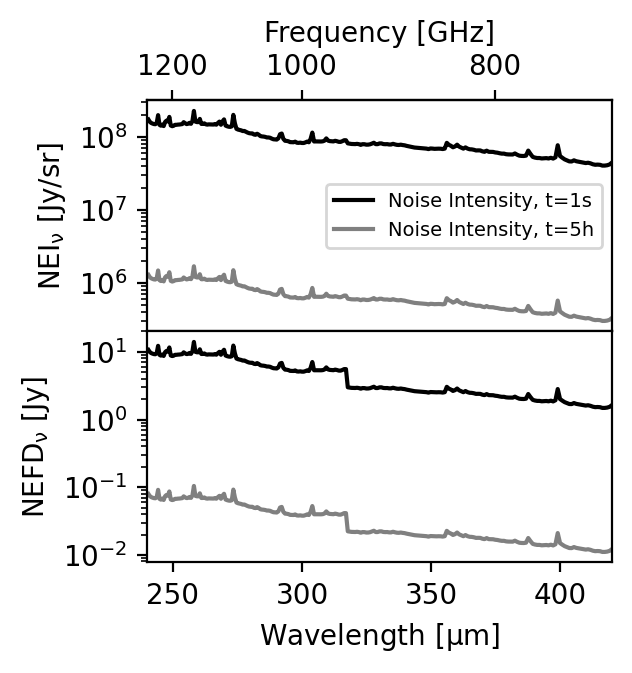

In [5]:
#compute the noise intensity out of the NEI and the survey time
t_survey = 5*3600 #Survey time in second

fig, (ax, ax2) = plt.subplots(2,figsize=(3,3), dpi=200, sharex=True )  
ax.loglog(lambdaw/1e3, noisew, label='Noise Intensity, t=1s', c='k' )
ax.loglog(lambdaw/1e3, noisew/np.sqrt(t_survey),  label='Noise Intensity, t=5h', c='grey') 

ax2.loglog(lambdaw/1e3, NEFDw, label='Noise Intensity, t=1s', c='k' )
ax2.loglog(lambdaw/1e3, NEFDw/np.sqrt(t_survey),  label='Noise Intensity, t=5h', c='grey') 
ax2.set_xlabel("Wavelength [$\\rm \\mu$m]")
ax.set_ylabel("NEI$\\rm _{\\nu}$ [Jy/sr]")
ax2.set_ylabel("NEFD$\\rm _{\\nu}$ [Jy]")

ax.set_xscale("linear")
ax.set_xlim(240,420)
def w_to_f(x): return cst.c/(x*1e-6)/1e9
secax = ax.secondary_xaxis("top", functions=(w_to_f,w_to_f))
secax.set_xlabel('Frequency [GHz]')
ax.legend(fontsize=7, loc='center right')
fig.subplots_adjust(wspace=0, hspace=0)

In [10]:
df_radec = pd.read_csv("reuter_2020_data/spt_dndz_tab_a1.txt", delimiter="\t", skiprows=3)
df_fluxes = pd.read_csv("reuter_2020_data/spt_dndz_tab_d1.txt", delimiter="\t", skiprows=3)
df_propa = pd.read_csv("reuter_2020_data/spt_dndz_tab_f1.txt", delimiter="\t", skiprows=3)
df_propb = pd.read_csv("reuter_2020_data/spt_dndz_tab_f1_kappa_wd03.txt", delimiter="\t", skiprows=3)
data = Table.read('reuter_2020_data/smg_dndz_tables.fits', hdu=1)
colors = cm.plasma(np.linspace(0,1,len(data)))
print(data.keys())

['spt_id', 'z_photo', 'zerr_photo', 'z_spec', 'zerr_spec', 'RA', 'DEC', 'cycle', 'S_3mm', 'err_3mm', 'S_150_raw', 'err_150', 'S_150_deb', 'err_150.1', 'S_220_raw', 'err_220', 'S_220_deb', 'err_220.1', 'S_870', 'err_870', 'S_500', 'err_500', 'S_350', 'err_350', 'S_250', 'err_250', 'S_160', 'err_160', 'S_100', 'err_100', 'amp_mbb', 'amp_err_mbb', 'Tdust_mbb', 'Tdust_err_mbb', 'L0_mbb', 'L0_err_mbb', 'beta_mbb', 'beta_err_mbb', 'lir_mbb', 'lir_err_mbb', 'lfir_mbb', 'lfir_err_mbb', 'fit_mbb', 'um_obs_mbb', 'rchi2_mbb', 'lir_pl', 'lir_err_pl', 'beta_pl', 'beta_err_pl', 'fit_pl', 'um_obs_pl', 'Tdust_pl', 'Tdust_err_pl', 'rchi2_pl', 'Lpeak', 'Lpeak_err', 'lens_model', 'mu', 'mu_err', 'int_lfir', 'int_lfir_err', 'int_Mdust', 'int_Mdust_errhi', 'int_Mdust_errlo', 'int_SFR', 'int_SFR_err', 'int_lir', 'int_lir_err', 'app_lfir', 'app_lfir_err', 'app_Mdust', 'app_Mdust_errhi', 'app_Mdust_errlo', 'app_SFR', 'app_SFR_err', 'app_lir', 'app_lir_err']


        Use Spectrum instead. [_py_warnings]
        Use Spectrum instead. [_py_warnings]
C:\Users\ASUS\AppData\Local\Temp\ipykernel_24940\759447969.py:26: RuntimeWarning: divide by zero encountered in divide
  def w_to_f(x): return cst.c/(x*1e-6)/1e9


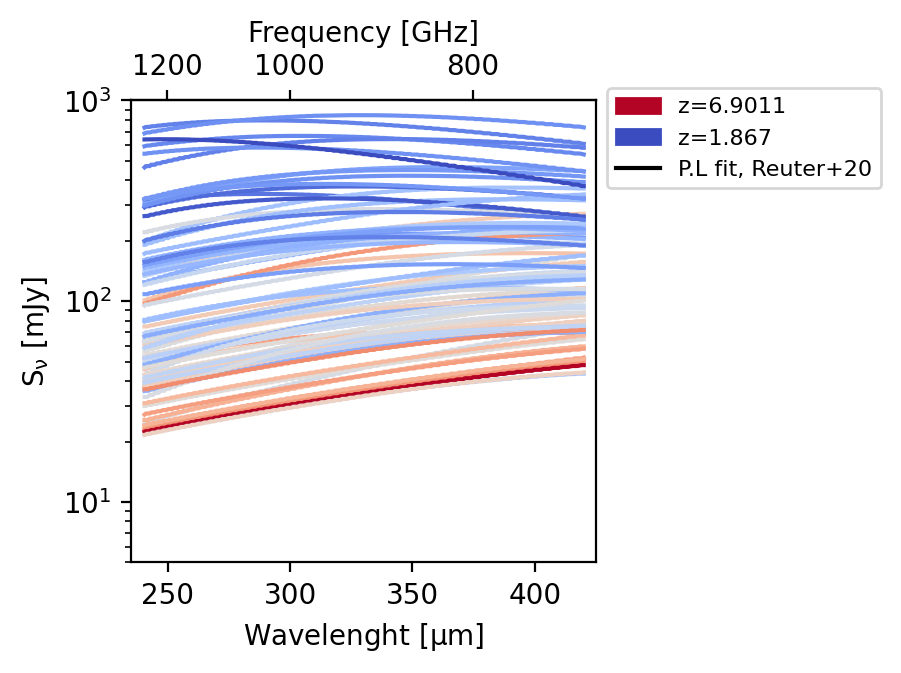

In [7]:
resample_grid =  (lambdaw/1e3*u.micron)

BS = 10; plt.rc('font', size=BS); plt.rc('axes', titlesize=BS); plt.rc('axes', labelsize=BS); mk = 3; lw=1
fig, ax = plt.subplots(figsize=(3, 3), dpi = 200)
patchs = []

colors = cm.Greys(np.linspace(0,1,len(data)))
for ismg, (smg, c) in enumerate(zip(data,colors)):

    #Redshift color coding
    zc = (smg['z_spec']-data['z_spec'].min())/(data['z_spec'].max()-data['z_spec'].min())
    c2 = cm.coolwarm(zc)
    if(zc==0 or zc==1.0): patch = mpatches.Patch(color=c2, label= f"z={smg['z_spec']}"); patchs.append(patch)
    spec = Spectrum1D(spectral_axis=(smg['um_obs_pl']*(1+smg['z_spec']))[:,0]*u.um, flux=smg['fit_pl'][:,0]*u.mJy)
    lambda_SED = spec.spectral_axis; SED = spec.flux
    input_spectra  = Spectrum1D( flux=SED, spectral_axis=lambda_SED)
    fluxc_resample = FluxConservingResampler()
    sed_in_tim = fluxc_resample(input_spectra, resample_grid) 
    ax.loglog(resample_grid, sed_in_tim.flux, c=c2)
    
ax.set_ylabel('$\\rm S_{\\nu}$ [mJy]'); 
ax.set_xlabel('Wavelenght [$\\rm \\mu$m]')
ax.set_yscale('log'); ax.set_xscale('linear')
ax.set_xlim(235,425)
ax.set_ylim(5e0, 1e3)
def w_to_f(x): return cst.c/(x*1e-6)/1e9
secax = ax.secondary_xaxis("top", functions=(w_to_f,w_to_f))
secax.set_xlabel('Frequency [GHz]')
patch = mlines.Line2D([], [], color='k',  linestyle="solid", label='P.L fit, Reuter+20'); patchs.append(patch)
ax.legend(handles = patchs, loc = 'upper left', fontsize=8, bbox_to_anchor=(1.0, 1.05))
fig.subplots_adjust(hspace=0, wspace=0)

Integration Time For One Line emission(z = 1.867, OI 145um)

In [8]:

z = 1.867
target_lambda =  cst.c / 2060.4292646 / 1e3 * (1 + z) #um

print(target_lambda)
resample_grid =  (lambdaw/1e3*u.micron)

for ismg, (smg, c) in enumerate(zip(data,colors)):
    spec = Spectrum1D(spectral_axis=(smg['um_obs_pl']*(1+smg['z_spec']))[:,0]*u.um, flux=smg['fit_pl'][:,0]*u.mJy)
    lambda_SED = spec.spectral_axis; SED = spec.flux
    input_spectra  = Spectrum1D( flux=SED, spectral_axis=lambda_SED)
    fluxc_resample = FluxConservingResampler()
    sed_in_tim = fluxc_resample(input_spectra, resample_grid) 
    if(smg['z_spec']==z):
        difference = np.abs((resample_grid.value) - target_lambda)
        closest_index = difference.argmin()
        target_fluxDensity = sed_in_tim.flux[closest_index]
        print("Target flux density at ", target_lambda, "um and z=", z, " is ", target_fluxDensity)
        target_noiseLevel = target_fluxDensity / 5.0 #5-sigma detection
        print("Target noise level for 5-sigma detection is ", target_noiseLevel)


#Now, find the noise level at that wavelength
difference = np.abs(lambdaw - target_lambda * 1e3)
closest_index = difference.argmin()
closest_lambda = lambdaw[closest_index]
corresponding_noise = NEFDw[closest_index]
print(closest_lambda, "nm")
print(corresponding_noise)
integration_time = (corresponding_noise/(target_noiseLevel / 1e3))**2
print(integration_time.value, "s")

417.14850000097397


        Use Spectrum instead. [_py_warnings]
        Use Spectrum instead. [_py_warnings]


Target flux density at  417.14850000097397 um and z= 1.867  is  381.0303039550781 mJy
Target noise level for 5-sigma detection is  76.20606079101563 mJy
417195.873 nm
1.4862223168442734 Jy
380.3544755768605 s


Integration Time For All Line Emissions

In [9]:
import pandas as pd
import numpy as np
import astropy.units as u


def getFluxAtLambda(rest_lambda, data, lambdaw):
    flux = []
    redshift = []
    lambdaw = lambdaw / 1e3  # convert to micron
    for i, spt_id in enumerate(data):
        spec = Spectrum1D(spectral_axis=(spt_id['um_obs_pl']*(1+spt_id['z_spec']))[:,0]*u.um, flux=spt_id['fit_pl'][:,0]*u.mJy)
        fluxc_resample = FluxConservingResampler()
        resample_grid = (lambdaw*u.micron)
        sed_in_tim = fluxc_resample(spec, resample_grid) 
        
        redshift.append(spt_id['z_spec']) 
        
        if (rest_lambda*(1+spt_id['z_spec']) < lambdaw.min()) or (rest_lambda*(1+spt_id['z_spec']) > lambdaw.max()):
            closest_flux = np.nan*u.Jy
            flux.append(closest_flux)
            continue
            
        closest_lambda = lambdaw[np.argmin(np.abs(lambdaw - rest_lambda*(1+spt_id['z_spec'])))]
        closest_flux = sed_in_tim.flux[np.argmin(np.abs(resample_grid - closest_lambda*u.micron))]
        flux.append(closest_flux)
    
    return flux, redshift

def get_All_NEFD(rest_lambda, redshift_list, lambdaw, NEFDw):
    NEFD = []
    lambdaw = lambdaw / 1e3  # convert to micron
    for rs in redshift_list:
        observed_lambda = rest_lambda*(1+rs)
        if (observed_lambda < lambdaw.min()) or (observed_lambda > lambdaw.max()):
            closest_NEFD = np.nan*u.Jy
            NEFD.append(closest_NEFD)
            continue
        closest_lambda = lambdaw[np.argmin(np.abs(lambdaw - observed_lambda))]
        closest_NEFD = NEFDw[np.argmin(np.abs(lambdaw - observed_lambda))]
        NEFD.append(closest_NEFD)
    return NEFD


target_nu = np.array(FIR_lines_nu)
target_lambda = cst.c/(target_nu*1e9)/1e-6 # in micron
final_data_list = []

print(target_lambda)


for j, (J, rest_lambda) in enumerate(zip(FIR_lines_list, target_lambda)):

    current_flux, current_redshift = getFluxAtLambda(rest_lambda, data, lambdaw)
    current_NEFD = get_All_NEFD(rest_lambda, current_redshift, lambdaw, NEFDw)
    
    for i, (f, n) in enumerate(zip(current_flux, current_NEFD)):
        # For 5-sigma detection
        # integration_time = (NEFD / target_noiseLevel)^2
        SNR_target = 5
        f_mJy = f.to(u.mJy) if hasattr(f, 'to') else f * u.mJy
        n_Jy = n.to(u.Jy) if hasattr(n, 'to') else n * u.Jy
        
        target_noiseLevel_mJy = f_mJy / SNR_target
        target_noiseLevel_Jy = target_noiseLevel_mJy.to(u.Jy)
        
        t_int_value = (n_Jy.value / target_noiseLevel_Jy.value)**2
        t_int = t_int_value * u.s
        
        print(f"Line: {J}, Source {i}, z={current_redshift[i]:.2f}, Flux={f_mJy:.2f}, NEFD={n_Jy:.2f}, t_int={t_int.to(u.hr):.2f}")
        
        final_data_list.append({
            'Line': J,
            'Source_ID': i,
            'Redshift': current_redshift[i],
            'Flux_Jy': f_mJy.to(u.Jy).value if hasattr(f_mJy, 'to') else float(f_mJy)/1000,
            'NEFD_Jy': n_Jy.value if hasattr(n_Jy, 'value') else float(n_Jy),
            't_int_hr': t_int.to(u.hr).value if hasattr(t_int, 'to') else float(t_int/3600)
        })

df = pd.DataFrame(final_data_list)
df.to_csv("obs_calculation_results.csv", index=False)


[ 33.48  34.82  51.81  57.32  63.16  88.36 121.9  145.5 ]


        Use Spectrum instead. [_py_warnings]


Line: SIII 33$\rm \mu m$, Source 0, z=2.35, Flux=nan mJy, NEFD=nan Jy, t_int=nan h
Line: SIII 33$\rm \mu m$, Source 1, z=4.12, Flux=nan mJy, NEFD=nan Jy, t_int=nan h
Line: SIII 33$\rm \mu m$, Source 2, z=3.44, Flux=nan mJy, NEFD=nan Jy, t_int=nan h
Line: SIII 33$\rm \mu m$, Source 3, z=4.88, Flux=nan mJy, NEFD=nan Jy, t_int=nan h
Line: SIII 33$\rm \mu m$, Source 4, z=3.09, Flux=nan mJy, NEFD=nan Jy, t_int=nan h
Line: SIII 33$\rm \mu m$, Source 5, z=4.91, Flux=nan mJy, NEFD=nan Jy, t_int=nan h
Line: SIII 33$\rm \mu m$, Source 6, z=3.61, Flux=nan mJy, NEFD=nan Jy, t_int=nan h
Line: SIII 33$\rm \mu m$, Source 7, z=3.44, Flux=nan mJy, NEFD=nan Jy, t_int=nan h
Line: SIII 33$\rm \mu m$, Source 8, z=4.23, Flux=nan mJy, NEFD=nan Jy, t_int=nan h
Line: SIII 33$\rm \mu m$, Source 9, z=2.51, Flux=nan mJy, NEFD=nan Jy, t_int=nan h
Line: SIII 33$\rm \mu m$, Source 10, z=3.96, Flux=nan mJy, NEFD=nan Jy, t_int=nan h
Line: SIII 33$\rm \mu m$, Source 11, z=4.30, Flux=nan mJy, NEFD=nan Jy, t_int=nan h
Li

KeyboardInterrupt: 